In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import psutil

from src.graph_utils.reading import read_graph6, read_metadata
from src.descriptors.edge_descriptors import edge_descriptors_dict
from src.descriptors.node_descriptors import node_descriptors_dict
from src.collision_tests.comparison import TestOperator

from src.settings import Settings


In [3]:
for filename in os.listdir(Settings.raw_datasets_dir):
    if '.txt' in filename:
        old_filename = os.path.join('raw_datasets', filename)
        new_filename = re.sub(r'.txt', '', old_filename)
        print(old_filename, new_filename)

        os.rename(old_filename, new_filename)

In [4]:
psutil.cpu_count()

12

In [5]:
single_features = [(k, ) for k in edge_descriptors_dict.keys()]

node_features = [(f, ) for f in list(filter(lambda k: 'ldp' not in k, node_descriptors_dict.keys()))]
node_features.extend([tuple(filter(lambda k: 'ldp' in k and 'normalized' not in k, node_descriptors_dict.keys()))])
node_features.extend([tuple(filter(lambda k: 'ldp' in k and ('normalized' in k or 'degree' in k), node_descriptors_dict.keys()))])

single_features.extend(node_features)


single_features = \
    single_features \
    + list(map(lambda params: tuple(map(lambda x: x + ':k_graph2', params)), single_features)) \
    + list(map(lambda params: tuple(map(lambda x: x + ':k_graph3', params)), single_features)) \
    + list(map(lambda params: tuple(map(lambda x: x + ':modk_graph2', params)), single_features)) \
    
single_features

# single_features = [('spanning_edge:k_graph3', )]

[('jaccard_index',),
 ('jaccard_index_normalized',),
 ('adamic_adar',),
 ('katz_index',),
 ('neighborhood_distance',),
 ('neighborhood_measure',),
 ('preferential_attachment',),
 ('resource_allocation',),
 ('same_community',),
 ('total_nieghbors',),
 ('algebraic_distance',),
 ('ari',),
 ('lds',),
 ('scan',),
 ('cn_quadrangle',),
 ('cn_triangle',),
 ('lss',),
 ('simmelian_sparsifier_np',),
 ('edge_betweenness',),
 ('edge_betweenness_normalized',),
 ('spanning_edge',),
 ('eigenvector_centrality',),
 ('closeness',),
 ('closeness_normalized',),
 ('degree_centrality',),
 ('degree_centrality_normalized',),
 ('katz_centrality',),
 ('lcc',),
 ('ldp_degree', 'ldp_min', 'ldp_max', 'ldp_mean', 'ldp_std'),
 ('ldp_degree',
  'ldp_min_normalized',
  'ldp_max_normalized',
  'ldp_mean_normalized',
  'ldp_std_normalized'),
 ('jaccard_index:k_graph2',),
 ('jaccard_index_normalized:k_graph2',),
 ('adamic_adar:k_graph2',),
 ('katz_index:k_graph2',),
 ('neighborhood_distance:k_graph2',),
 ('neighborhood_me

In [27]:
import os
from typing import List
from src.graph_utils.dataset import Dataset
from src.collision_tests.utils import TestParameters

arguments_list = []
datasets: List[Dataset] = []
for dataset_name in ['graph5', 'graph6', 'graph7']:
# for dataset_name in  map(lambda x: '.'.join(x.split('.')[:-1]), filter(lambda x: '.g6' in x, os.listdir(READ_DIR))):
    dataset = Dataset(name=dataset_name)
    datasets.append(dataset)
    for features in single_features:
    
        features = features
        arguments_list.append(TestParameters(dataset=dataset,
                                    features=features))

In [28]:
from tqdm import tqdm
for dataset in tqdm(datasets):
    dataset.generate_k_graph_cache(k=2)
    dataset.generate_k_graph_cache(k=3)
    dataset.generate_k_graph_cache(k=2, modified=True)


100%|██████████| 3/3 [00:00<00:00, 30.86it/s]


In [29]:
test_operator = TestOperator(single_thread=True)

test_operator.tests(arguments_list)

  0%|          | 0/360 [00:00<?, ?it/s]

c:\Users\Przemek\Documents\Studia\10_semestr\magisterka\Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem\src\descriptors\node_descriptors.py:101: RuntimeWarning: invalid value encountered in divide
  return degree_matrix.sum(axis=1) / degrees
c:\Users\Przemek\Documents\Studia\10_semestr\magisterka\Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem\src\descriptors\node_descriptors.py:107: RuntimeWarning: invalid value encountered in divide
  mean_degree = degree_matrix.sum(axis=1) / degrees
c:\Users\Przemek\Documents\Studia\10_semestr\magisterka\Analysis-of-graph-topological-descriptors-for-the-graph-isomorphism-problem\src\descriptors\node_descriptors.py:108: RuntimeWarning: invalid value encountered in divide
  return (degree_matrix**2).sum(axis=1) / degrees - mean_degree**2


  0%|          | 0/360 [00:00<?, ?it/s]

In [30]:
metadata = read_metadata()

In [31]:
from collections import Counter

def count_elements(row_array):
    if len(row_array) == 1 and row_array[0] == -1:
        return 0
    return len(row_array)

test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [32]:
test_data = test_data.reset_index(drop=True)
test_data

,features,dataset_name,result,count,percentage
0,[jaccard_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
1,[jaccard_index_normalized],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
2,[adamic_adar],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
3,[katz_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
4,[neighborhood_distance],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
...,...,...,...,...,...
355,[degree_centrality_normalized:modk_graph2],graph7,"[0, 1, 7, 11, 57, 59, 113, 346, 354, 356, 568,...",994,0.952107
356,[katz_centrality:modk_graph2],graph7,"[0, 1, 7, 11, 57, 59, 113, 346, 354, 356, 432,...",885,0.847701
357,[lcc:modk_graph2],graph7,"[0, 1, 2, 7, 8, 11, 12, 13, 20, 24, 29, 30, 57...",1006,0.963602
358,"[ldp_degree:modk_graph2, ldp_max:modk_graph2, ...",graph7,"[0, 1, 7, 11, 57, 59, 113, 346, 354, 356, 568,...",883,0.845785


In [33]:
test_data['result'].iloc[0]

array([ 2,  5,  3,  6,  8,  4, 10, 13, 20, 11, 12, 21,  9, 19, 16, 24, 15,
       26])

In [34]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

In [35]:
test_data['features'].iloc[0]

"['jaccard_index']"

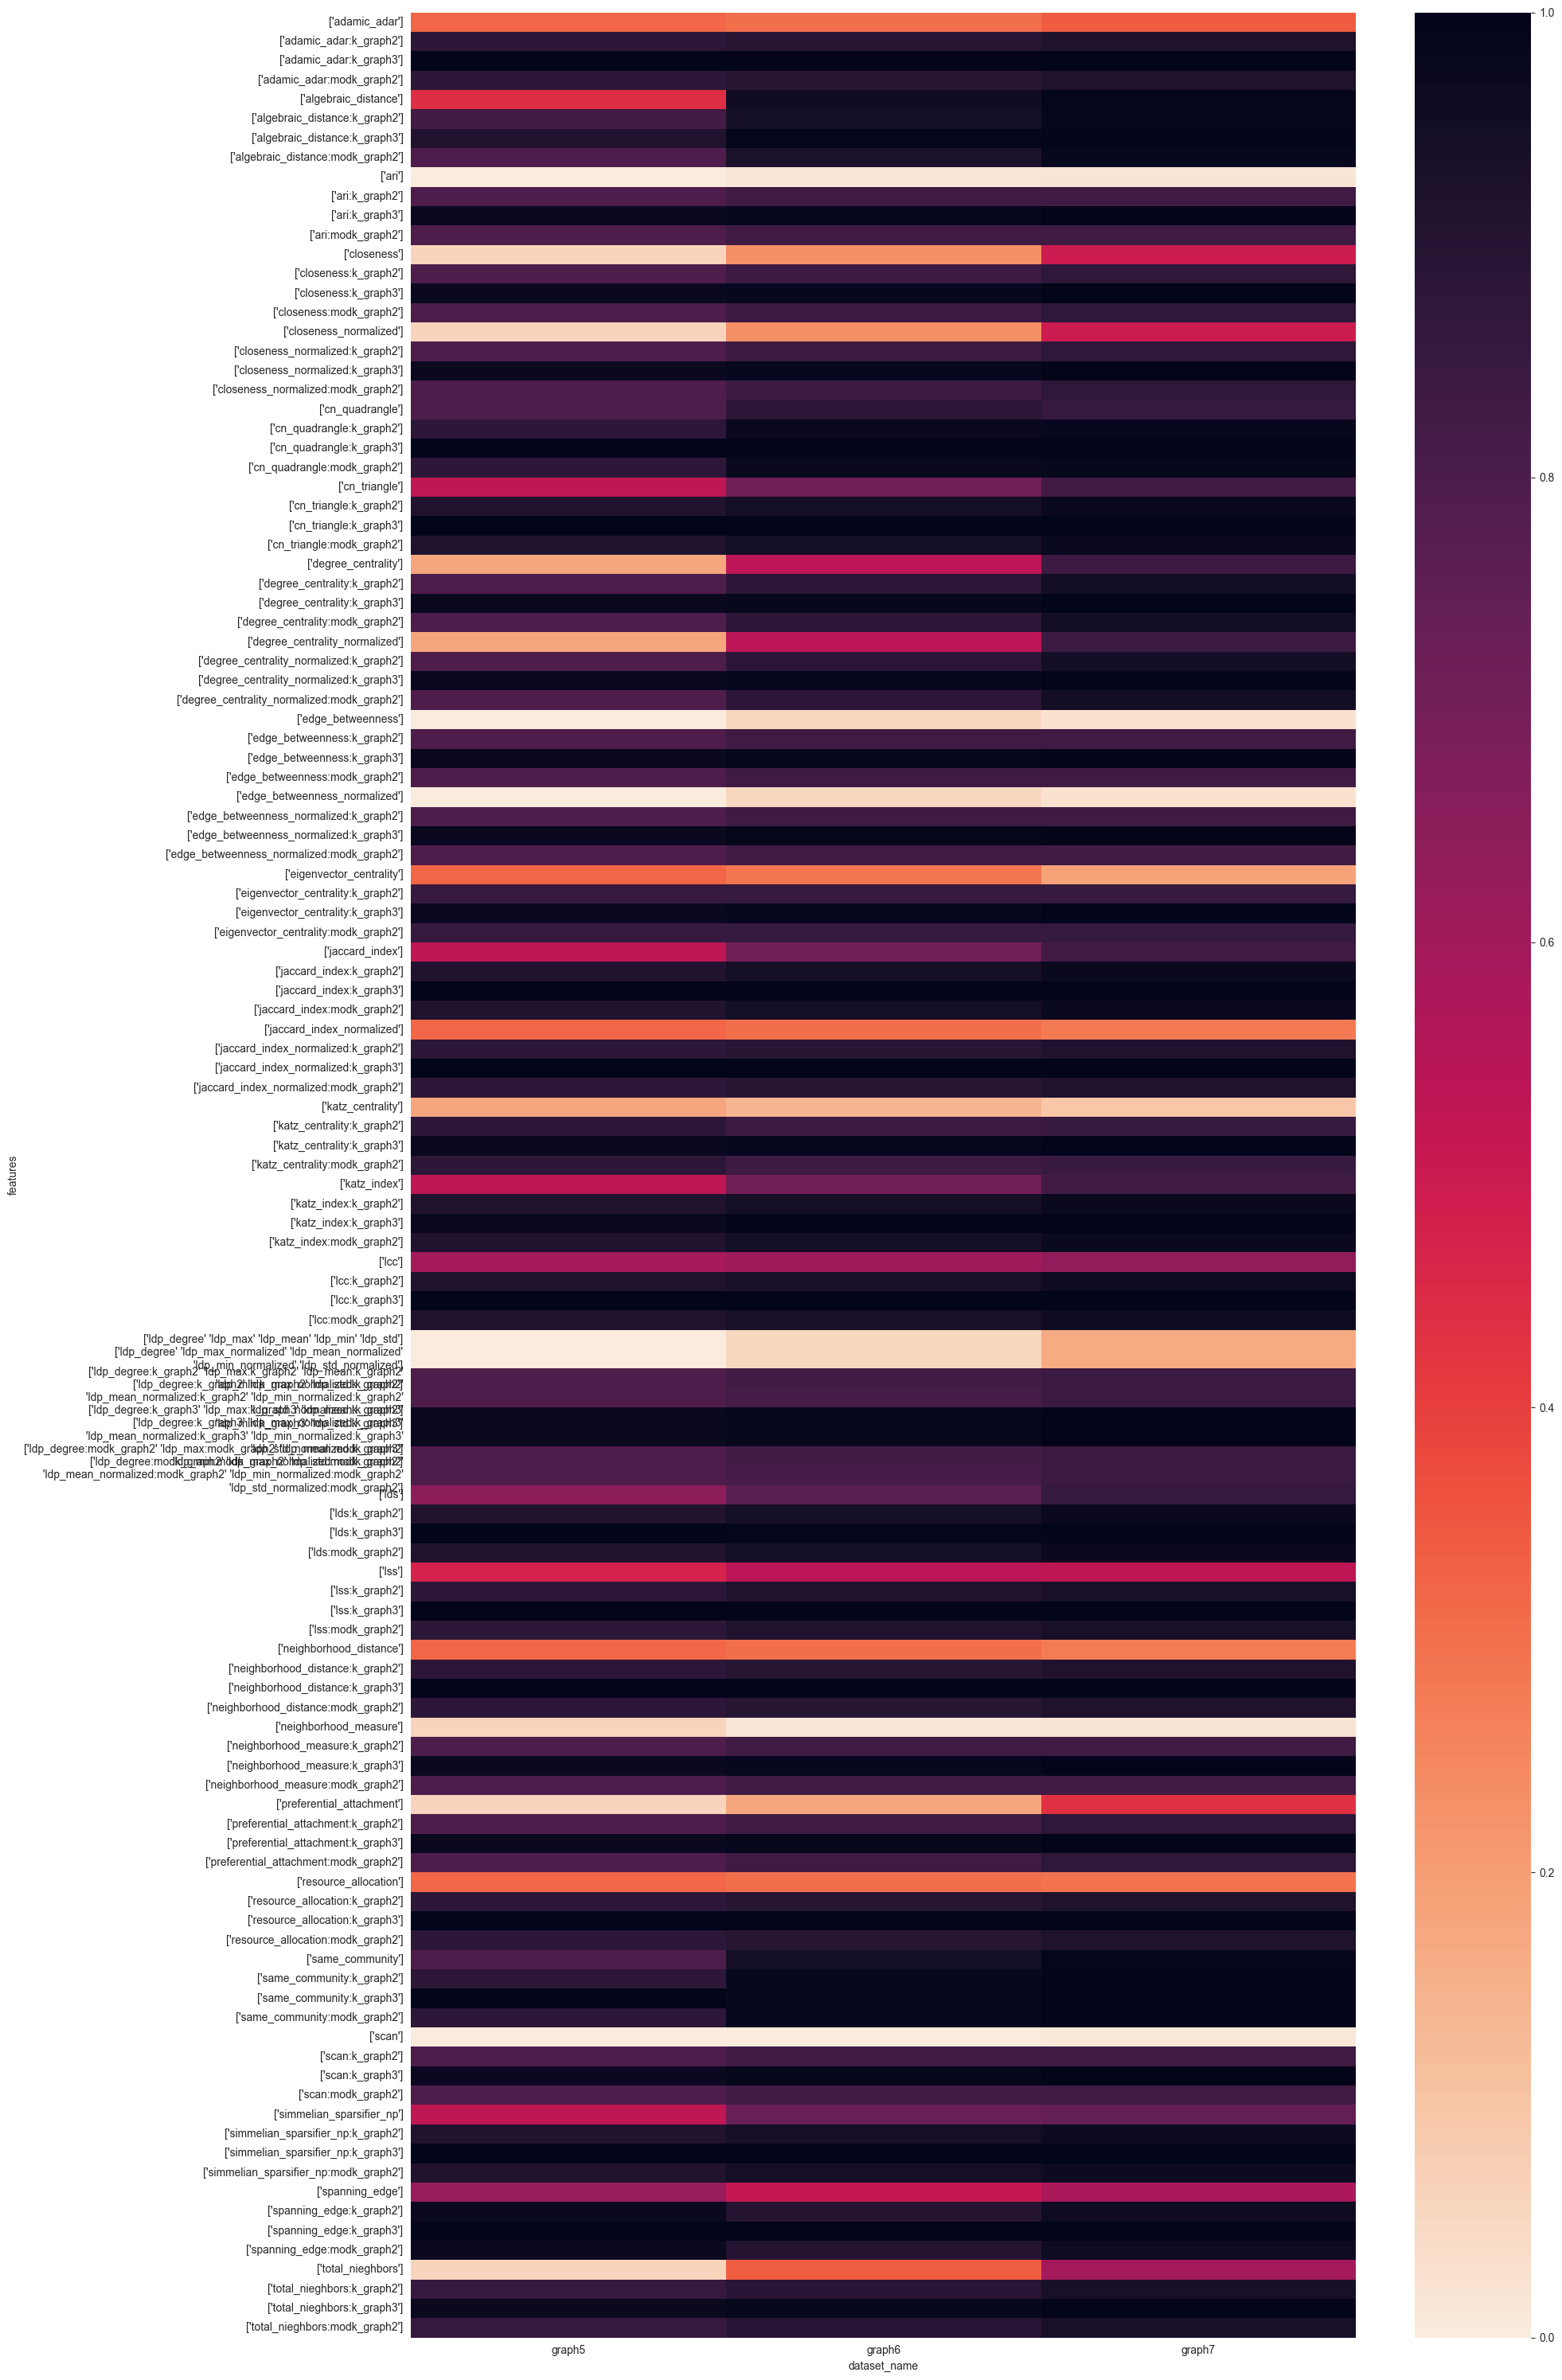

In [36]:
# data2d = test_data[~test_data['features'].str.contains('graph')].pivot(index="features", columns="dataset_name", values="percentage")
# data2d = test_data[test_data['features'].str.contains(':k_graph2')].pivot(index="features", columns="dataset_name", values="percentage")

data2d = test_data.pivot(index="features", columns="dataset_name", values="percentage")


data2d = data2d.sort_index()

g = sns.heatmap(data=data2d, cmap='rocket_r', vmin=0, vmax=1)
fig = plt.gcf()
fig.set_size_inches(20,30)
plt.tight_layout()

g.set_yticks(np.arange(data2d.shape[0]) + 0.5)

_ = g.set_yticklabels(data2d.index)

g.set_xticks(np.arange(data2d.shape[1]) + 0.5)

_ = g.set_xticklabels(data2d.columns)
